# Step 7: RAG Evaluation - Retrieval Metrics

This notebook evaluates the Step 5/6 retriever on the household energy dataset.

Scope:
- Load a curated evaluation dataset with questions and relevant chunk IDs.
- Reuse the chunk and embedding artifacts from Step 5.
- Evaluate dense retrieval and hybrid retrieval.
- Compute Precision@K, Recall@K, Hit@K, MRR, nDCG@K, and AP.
- Summarize the retrieval results and interpret what they mean.


## Cell Guide: Install Dependencies

This cell installs the libraries needed for retrieval evaluation and metric computation.


In [ ]:
!pip install -q google-cloud-aiplatform python-dotenv sentence-transformers pandas numpy matplotlib seaborn

In [25]:
!pip install matplotlib seaborn --upgrade

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


## Cell Guide: Load Libraries and Configuration

This cell loads environment variables, initializes Vertex AI when endpoint settings are available, and prepares notebook-wide state.


In [26]:
import os
import re
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from dotenv import find_dotenv, load_dotenv
from google.api_core.exceptions import GoogleAPICallError, ServiceUnavailable
from google.auth.exceptions import DefaultCredentialsError
from google.cloud import aiplatform
from sentence_transformers import SentenceTransformer

load_dotenv(find_dotenv(usecwd=True), override=False)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "src":
    PROJECT_ROOT = PROJECT_ROOT.parent

REQUIRED_ENV_VARS = ["PROJECT_ID", "REGION", "EMBEDDING_MODEL_NAME"]
missing = [key for key in REQUIRED_ENV_VARS if not os.getenv(key)]
if missing:
    raise ValueError(
        "Missing required environment variables: "
        + ", ".join(missing)
        + ". Update .env before running Step 7."
    )

CONFIG = {key: os.getenv(key) for key in REQUIRED_ENV_VARS}
CONFIG["DEPLOYED_INDEX_ID"] = os.getenv("DEPLOYED_INDEX_ID", "")
CONFIG["VERTEX_ENDPOINT_ID"] = os.getenv("VERTEX_ENDPOINT_ID", "")
CONFIG["VERTEX_ENDPOINT_RESOURCE_NAME"] = os.getenv("VERTEX_ENDPOINT_RESOURCE_NAME", "")
CONFIG["EVAL_TOP_K"] = int(os.getenv("EVAL_TOP_K", "3"))

RUN_STATE = {}


def mark_step(step, status, detail):
    RUN_STATE[step] = {
        "status": status,
        "detail": detail,
        "timestamp": datetime.now(UTC).isoformat(timespec="seconds").replace("+00:00", "Z"),
    }


def auth_help():
    return (
        "Google Cloud authentication is required. Run:\n"
        "gcloud auth application-default login\n"
        f"gcloud config set project {CONFIG['PROJECT_ID']}"
    )


vertex_endpoint = None
endpoint_name = CONFIG["VERTEX_ENDPOINT_RESOURCE_NAME"]
if not endpoint_name and CONFIG["VERTEX_ENDPOINT_ID"]:
    endpoint_name = (
        f"projects/{CONFIG['PROJECT_ID']}/locations/{CONFIG['REGION']}"
        f"/indexEndpoints/{CONFIG['VERTEX_ENDPOINT_ID']}"
    )

if endpoint_name:
    try:
        aiplatform.init(project=CONFIG["PROJECT_ID"], location=CONFIG["REGION"])
        vertex_endpoint = aiplatform.MatchingEngineIndexEndpoint(endpoint_name)
        print("vertex_endpoint:", endpoint_name)
        mark_step("vertex_endpoint", "passed", f"Connected to endpoint {endpoint_name}.")
    except DefaultCredentialsError as exc:
        raise RuntimeError(auth_help()) from exc
else:
    mark_step("vertex_endpoint", "skipped", "No Vertex endpoint configured; evaluation will use local retrieval only.")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROJECT_ID:", CONFIG["PROJECT_ID"])
print("REGION:", CONFIG["REGION"])
print("EVAL_TOP_K:", CONFIG["EVAL_TOP_K"])
mark_step("environment_loaded", "passed", "Environment and evaluation configuration loaded.")


vertex_endpoint: projects/313902583160/locations/asia-southeast1/indexEndpoints/7725529336568086528
PROJECT_ROOT: D:\Intern
PROJECT_ID: rag-project-495601
REGION: asia-southeast1
EVAL_TOP_K: 3


## Cell Guide: Load Evaluation Data and Retrieval Artifacts

This cell loads the curated evaluation questions together with the chunk and embedding artifacts produced in Step 5.


In [27]:
eval_path = PROJECT_ROOT / "data" / "evals" / "step7_retrieval_eval.csv"
artifact_dir = PROJECT_ROOT / "data" / "artifacts" / "vertex_vector_search"
chunk_csv_path = artifact_dir / "energy_chunks.csv"
embeddings_npy_path = artifact_dir / "energy_embeddings.npy"

for path in [eval_path, chunk_csv_path, embeddings_npy_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required Step 7 file: {path}")

eval_df = pd.read_csv(eval_path)
chunk_df = pd.read_csv(chunk_csv_path)
embeddings = np.load(embeddings_npy_path)
embedding_model = SentenceTransformer(CONFIG["EMBEDDING_MODEL_NAME"])

eval_df["relevant_chunk_ids"] = eval_df["relevant_chunk_ids"].fillna("").apply(lambda value: value.split("|") if value else [])
print("Evaluation questions:", len(eval_df))
print("Chunks:", len(chunk_df))
print("Embedding shape:", embeddings.shape)
display(eval_df.head(5))
mark_step("eval_data_loaded", "passed", f"Loaded {len(eval_df)} evaluation questions and {len(chunk_df)} chunks.")


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 5075.74it/s]


Evaluation questions: 56
Chunks: 23
Embedding shape: (23, 1024)


,question,relevant_chunk_ids,notes
0,What assumptions are used in the household ene...,"[energy_chunk_0001, energy_chunk_0006, energy_...",High-level assumptions and methodology overview
1,Which household types are included in the anal...,"[energy_chunk_0002, energy_chunk_0004]",Household type list on page 2
2,In what dollar basis are the results expressed?,"[energy_chunk_0002, energy_chunk_0004]",Real 2026 dollars statement
3,What gas usage assumption is made per household?,"[energy_chunk_0006, energy_chunk_0009]",Current usage data assumptions
4,What petrol or ICE vehicle assumption is used ...,"[energy_chunk_0006, energy_chunk_0007, energy_...",Vehicle ownership and fuel efficiency assumptions


## Cell Guide: Build Dense and Hybrid Retrievers

This cell defines the dense retriever and the hybrid retriever used for the Step 7 metric comparison.


In [28]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "of", "to", "in", "for", "with", "on", "is", "are", "be", "by",
    "what", "which", "how", "when", "where", "why", "it", "this", "that", "from", "as", "at",
}

chunk_id_to_index = {chunk_id: idx for idx, chunk_id in enumerate(chunk_df["chunk_id"].tolist())}
id_to_row = chunk_df.set_index("chunk_id").to_dict(orient="index")


def tokenize(text):
    return [token for token in re.findall(r"[a-z0-9]+", str(text).lower()) if token not in STOPWORDS]


def keyword_score(query, text):
    query_tokens = tokenize(query)
    text_tokens = tokenize(text)
    if not query_tokens or not text_tokens:
        return 0.0
    text_counts = pd.Series(text_tokens).value_counts().to_dict()
    overlap = sum(min(text_counts.get(token, 0), 1) for token in query_tokens)
    coverage = overlap / max(len(set(query_tokens)), 1)
    density = overlap / max(len(text_tokens), 1)
    return float((0.85 * coverage) + (0.15 * density))


def local_dense_retrieve(query, candidate_k=None):
    candidate_k = candidate_k or CONFIG["EVAL_TOP_K"]
    query_vector = embedding_model.encode([f"query: {query}"], normalize_embeddings=True, convert_to_numpy=True)[0]
    scores = embeddings @ query_vector
    top_indices = np.argsort(-scores)[:candidate_k]
    result = chunk_df.iloc[top_indices].copy().reset_index(drop=True)
    result["dense_score"] = scores[top_indices]
    result["retrieval_backend"] = "local_dense"
    return result


def vertex_dense_retrieve(query, candidate_k=None):
    candidate_k = candidate_k or CONFIG["EVAL_TOP_K"]
    if vertex_endpoint is None or not CONFIG["DEPLOYED_INDEX_ID"]:
        return pd.DataFrame()
    try:
        query_vector = embedding_model.encode([f"query: {query}"], normalize_embeddings=True, convert_to_numpy=True)[0].astype(float).tolist()
        response = vertex_endpoint.find_neighbors(
            deployed_index_id=CONFIG["DEPLOYED_INDEX_ID"],
            queries=[query_vector],
            num_neighbors=candidate_k,
            return_full_datapoint=True,
        )
    except (ServiceUnavailable, GoogleAPICallError, Exception) as exc:
        print(f"Vertex retrieval fallback triggered: {exc}")
        return pd.DataFrame()

    if not response or not response[0]:
        return pd.DataFrame()

    rows = []
    for neighbor in response[0]:
        metadata = getattr(neighbor, "embedding_metadata", None) or {}
        local_row = id_to_row.get(neighbor.id, {})
        rows.append({
            "chunk_id": neighbor.id,
            "content": metadata.get("content") or local_row.get("content"),
            "page_number": metadata.get("page_number") or local_row.get("page_number"),
            "section_tag": metadata.get("section_tag") or local_row.get("section_tag"),
            "dense_score": 1 - float(getattr(neighbor, "distance", 1.0)),
            "retrieval_backend": "vertex_dense",
        })
    return pd.DataFrame(rows)


def dense_retrieve(query, candidate_k=None):
    result = vertex_dense_retrieve(query, candidate_k=candidate_k)
    if result.empty:
        result = local_dense_retrieve(query, candidate_k=candidate_k)
    return result


def hybrid_retrieve(query, top_k=None, candidate_k=None):
    top_k = top_k or CONFIG["EVAL_TOP_K"]
    candidate_k = candidate_k or max(top_k * 3, 8)
    dense_df = dense_retrieve(query, candidate_k=candidate_k)
    keyword_df = chunk_df.copy()
    keyword_df["keyword_score"] = keyword_df["content"].apply(lambda text: keyword_score(query, text))
    keyword_df = keyword_df.sort_values(["keyword_score", "char_count"], ascending=[False, False]).head(candidate_k)

    candidate_ids = set(dense_df.get("chunk_id", pd.Series(dtype=str)).tolist())
    candidate_ids.update(keyword_df["chunk_id"].tolist())
    combined = chunk_df[chunk_df["chunk_id"].isin(candidate_ids)].copy()
    combined = combined.merge(dense_df[["chunk_id", "dense_score", "retrieval_backend"]], on="chunk_id", how="left")
    combined = combined.merge(keyword_df[["chunk_id", "keyword_score"]], on="chunk_id", how="left")
    combined[["dense_score", "keyword_score"]] = combined[["dense_score", "keyword_score"]].fillna(0.0)
    combined["retrieval_backend"] = combined["retrieval_backend"].fillna("local_hybrid")
    combined["hybrid_score"] = (0.75 * combined["dense_score"]) + (0.25 * combined["keyword_score"])
    combined["rerank_score"] = combined["hybrid_score"] + np.where(combined["keyword_score"] > 0, 0.02, 0.0)
    combined = combined.sort_values(["rerank_score", "dense_score", "keyword_score"], ascending=[False, False, False])
    return combined.head(top_k).reset_index(drop=True)


mark_step("retrievers_ready", "passed", "Built dense and hybrid retrieval functions for evaluation.")
print(RUN_STATE["retrievers_ready"])


{'status': 'passed', 'detail': 'Built dense and hybrid retrieval functions for evaluation.', 'timestamp': '2026-05-14T04:12:31Z'}


## Cell Guide: Define Retrieval Metrics

This cell implements the standard retrieval metrics required for Step 7.


In [29]:
def precision_at_k(retrieved_ids, relevant_ids, k):
    retrieved_at_k = retrieved_ids[:k]
    if not retrieved_at_k:
        return 0.0
    hits = sum(1 for chunk_id in retrieved_at_k if chunk_id in relevant_ids)
    return hits / k


def recall_at_k(retrieved_ids, relevant_ids, k):
    if not relevant_ids:
        return 0.0
    retrieved_at_k = retrieved_ids[:k]
    hits = sum(1 for chunk_id in retrieved_at_k if chunk_id in relevant_ids)
    return hits / len(relevant_ids)


def hit_at_k(retrieved_ids, relevant_ids, k):
    retrieved_at_k = retrieved_ids[:k]
    return 1.0 if any(chunk_id in relevant_ids for chunk_id in retrieved_at_k) else 0.0


def reciprocal_rank(retrieved_ids, relevant_ids):
    for rank, chunk_id in enumerate(retrieved_ids, start=1):
        if chunk_id in relevant_ids:
            return 1.0 / rank
    return 0.0


def dcg_at_k(retrieved_ids, relevant_ids, k):
    score = 0.0
    for rank, chunk_id in enumerate(retrieved_ids[:k], start=1):
        relevance = 1.0 if chunk_id in relevant_ids else 0.0
        if relevance > 0:
            score += relevance / np.log2(rank + 1)
    return score


def ndcg_at_k(retrieved_ids, relevant_ids, k):
    ideal_hits = min(len(relevant_ids), k)
    if ideal_hits == 0:
        return 0.0
    ideal_ids = list(relevant_ids)[:ideal_hits]
    ideal_dcg = dcg_at_k(ideal_ids, set(ideal_ids), ideal_hits)
    if ideal_dcg == 0:
        return 0.0
    return dcg_at_k(retrieved_ids, relevant_ids, k) / ideal_dcg


def average_precision(retrieved_ids, relevant_ids):
    if not relevant_ids:
        return 0.0
    precisions = []
    hits = 0
    for rank, chunk_id in enumerate(retrieved_ids, start=1):
        if chunk_id in relevant_ids:
            hits += 1
            precisions.append(hits / rank)
    if not precisions:
        return 0.0
    return sum(precisions) / len(relevant_ids)


mark_step("metrics_ready", "passed", "Defined Precision@K, Recall@K, Hit@K, MRR, nDCG@K, and AP metrics.")
print(RUN_STATE["metrics_ready"])


{'status': 'passed', 'detail': 'Defined Precision@K, Recall@K, Hit@K, MRR, nDCG@K, and AP metrics.', 'timestamp': '2026-05-14T04:12:31Z'}


## Cell Guide: Run the Retrieval Evaluation

This cell runs the evaluation dataset through the dense and hybrid retrievers and computes the retrieval metrics per question.


In [30]:
def evaluate_retriever(eval_frame, retriever_name, retriever_fn, k):
    rows = []
    for _, row in eval_frame.iterrows():
        result_df = retriever_fn(row["question"], k)
        retrieved_ids = result_df["chunk_id"].tolist() if not result_df.empty else []
        relevant_ids = set(row["relevant_chunk_ids"])
        backend = result_df["retrieval_backend"].iloc[0] if not result_df.empty and "retrieval_backend" in result_df.columns else retriever_name
        rows.append({
            "retriever": retriever_name,
            "question": row["question"],
            "retrieval_backend": backend,
            "relevant_chunk_ids": list(relevant_ids),
            "retrieved_chunk_ids": retrieved_ids,
            f"precision@{k}": precision_at_k(retrieved_ids, relevant_ids, k),
            f"recall@{k}": recall_at_k(retrieved_ids, relevant_ids, k),
            f"hit@{k}": hit_at_k(retrieved_ids, relevant_ids, k),
            "mrr": reciprocal_rank(retrieved_ids, relevant_ids),
            f"ndcg@{k}": ndcg_at_k(retrieved_ids, relevant_ids, k),
            "ap": average_precision(retrieved_ids, relevant_ids),
        })
    return pd.DataFrame(rows)


K = CONFIG["EVAL_TOP_K"]
dense_eval_df = evaluate_retriever(eval_df, "dense", lambda query, top_k: dense_retrieve(query, candidate_k=top_k), K)
hybrid_eval_df = evaluate_retriever(eval_df, "hybrid", lambda query, top_k: hybrid_retrieve(query, top_k=top_k, candidate_k=max(top_k * 3, 8)), K)
per_question_eval_df = pd.concat([dense_eval_df, hybrid_eval_df], ignore_index=True)
display(per_question_eval_df)
mark_step("evaluation_run", "passed", f"Ran dense and hybrid retrieval evaluation on {len(eval_df)} questions.")


,retriever,question,retrieval_backend,relevant_chunk_ids,retrieved_chunk_ids,precision@3,recall@3,hit@3,mrr,ndcg@3,ap
0,dense,What assumptions are used in the household ene...,vertex_dense,"[energy_chunk_0001, energy_chunk_0011, energy_...","[energy_chunk_0000, energy_chunk_0011, energy_...",0.666667,0.666667,1.0,0.5,0.530721,0.388889
1,dense,Which household types are included in the anal...,vertex_dense,"[energy_chunk_0004, energy_chunk_0002]","[energy_chunk_0002, energy_chunk_0004, energy_...",0.666667,1.000000,1.0,1.0,1.000000,1.000000
2,dense,In what dollar basis are the results expressed?,vertex_dense,"[energy_chunk_0004, energy_chunk_0002]","[energy_chunk_0005, energy_chunk_0020, energy_...",0.000000,0.000000,0.0,0.0,0.000000,0.000000
3,dense,What gas usage assumption is made per household?,vertex_dense,"[energy_chunk_0009, energy_chunk_0006]","[energy_chunk_0006, energy_chunk_0009, energy_...",0.666667,1.000000,1.0,1.0,1.000000,1.000000
4,dense,What petrol or ICE vehicle assumption is used ...,vertex_dense,"[energy_chunk_0009, energy_chunk_0007, energy_...","[energy_chunk_0006, energy_chunk_0009, energy_...",0.666667,0.666667,1.0,1.0,0.765361,0.666667
...,...,...,...,...,...,...,...,...,...,...,...
107,hybrid,What does the report assume about gas and elec...,vertex_dense,[energy_chunk_0008],"[energy_chunk_0016, energy_chunk_0008, energy_...",0.333333,1.000000,1.0,0.5,0.630930,0.500000
108,hybrid,What is the base daily usage for dual fuel plu...,vertex_dense,"[energy_chunk_0014, energy_chunk_0012]","[energy_chunk_0012, energy_chunk_0013, energy_...",0.666667,1.000000,1.0,1.0,0.919721,0.833333
109,hybrid,What is the base daily usage for electrified h...,vertex_dense,"[energy_chunk_0014, energy_chunk_0012]","[energy_chunk_0012, energy_chunk_0014, energy_...",0.666667,1.000000,1.0,1.0,1.000000,1.000000
110,hybrid,What is the base usage description for EV only...,vertex_dense,"[energy_chunk_0013, energy_chunk_0014]","[energy_chunk_0013, energy_chunk_0014, energy_...",0.666667,1.000000,1.0,1.0,1.000000,1.000000


## Cell Guide: Aggregate and Interpret the Metrics

This cell aggregates the metric results across all questions and prints a short interpretation of the retriever quality.


In [31]:
metric_columns = [f"precision@{K}", f"recall@{K}", f"hit@{K}", "mrr", f"ndcg@{K}", "ap"]
aggregate_metrics_df = per_question_eval_df.groupby("retriever")[metric_columns].mean().reset_index()
aggregate_metrics_df = aggregate_metrics_df.rename(columns={"ap": "map"})
display(aggregate_metrics_df)

best_row = aggregate_metrics_df.sort_values([f"ndcg@{K}", "map"], ascending=[False, False]).iloc[0]
best_retriever = best_row["retriever"]
interpretation = (
    f"At K={K}, the {best_retriever} retriever currently gives the strongest ranking quality based on nDCG and MAP. "
    f"Use Precision@{K} to understand how clean the top results are, Recall@{K} to understand how many relevant chunks are recovered, "
    "MRR to understand how early the first relevant chunk appears, and Hit@K to understand whether the retriever finds at least one relevant chunk."
)
print(interpretation)
mark_step("evaluation_summary", "passed", f"Computed aggregate retrieval metrics and interpretation at K={K}.")


,retriever,precision@3,recall@3,hit@3,mrr,ndcg@3,map
0,dense,0.363095,0.592262,0.750000,0.654762,0.574532,0.524802
1,hybrid,0.476190,0.758929,0.928571,0.797619,0.728959,0.672619


At K=3, the hybrid retriever currently gives the strongest ranking quality based on nDCG and MAP. Use Precision@3 to understand how clean the top results are, Recall@3 to understand how many relevant chunks are recovered, MRR to understand how early the first relevant chunk appears, and Hit@K to understand whether the retriever finds at least one relevant chunk.


## Cell Guide: Visualize Retrieval Metrics

This cell creates charts to compare dense and hybrid retrieval performance so the Step 7 results are easier to interpret visually.


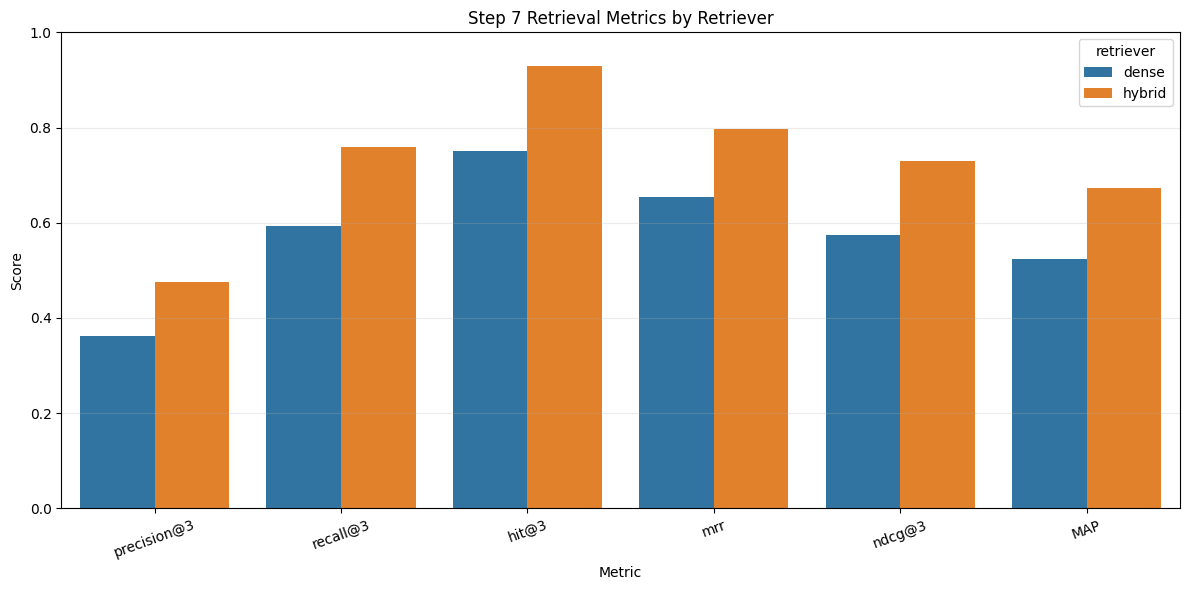

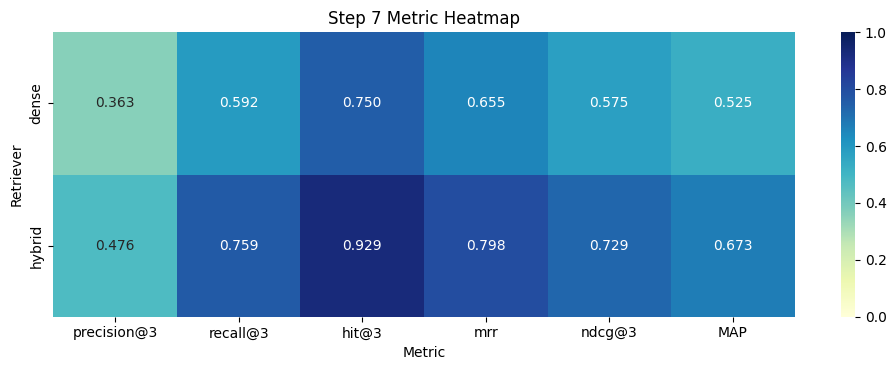

{'status': 'passed', 'detail': 'Generated bar chart and heatmap for retrieval metric comparison.', 'timestamp': '2026-05-14T04:13:16Z'}


In [32]:
plot_df = aggregate_metrics_df.copy()
plot_df = plot_df.rename(columns={"map": "MAP"})
metric_plot_columns = [f"precision@{K}", f"recall@{K}", f"hit@{K}", "mrr", f"ndcg@{K}", "MAP"]

long_plot_df = plot_df.melt(
    id_vars="retriever",
    value_vars=metric_plot_columns,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=long_plot_df, x="metric", y="score", hue="retriever")
plt.ylim(0, 1)
plt.title("Step 7 Retrieval Metrics by Retriever")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

heatmap_df = plot_df.set_index("retriever")[metric_plot_columns]
plt.figure(figsize=(10, 3.8))
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", vmin=0, vmax=1, fmt=".3f")
plt.title("Step 7 Metric Heatmap")
plt.ylabel("Retriever")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

mark_step("visualization", "passed", "Generated bar chart and heatmap for retrieval metric comparison.")
print(RUN_STATE["visualization"])


## Cell Guide: Summarize Step 7 Completion

This cell summarizes whether the Step 7 milestone has been reached.


In [33]:
test_results_df = pd.DataFrame([
    {"step": step, **payload}
    for step, payload in RUN_STATE.items()
])
display(test_results_df)

summary_rows = [
    {"test_area": "Environment setup", "status": RUN_STATE.get("environment_loaded", {}).get("status", "not_run"), "evidence": RUN_STATE.get("environment_loaded", {}).get("detail", "")},
    {"test_area": "Evaluation data loading", "status": RUN_STATE.get("eval_data_loaded", {}).get("status", "not_run"), "evidence": RUN_STATE.get("eval_data_loaded", {}).get("detail", "")},
    {"test_area": "Retriever definitions", "status": RUN_STATE.get("retrievers_ready", {}).get("status", "not_run"), "evidence": RUN_STATE.get("retrievers_ready", {}).get("detail", "")},
    {"test_area": "Metric definitions", "status": RUN_STATE.get("metrics_ready", {}).get("status", "not_run"), "evidence": RUN_STATE.get("metrics_ready", {}).get("detail", "")},
    {"test_area": "Evaluation run", "status": RUN_STATE.get("evaluation_run", {}).get("status", "not_run"), "evidence": RUN_STATE.get("evaluation_run", {}).get("detail", "")},
    {"test_area": "Metric interpretation", "status": RUN_STATE.get("evaluation_summary", {}).get("status", "not_run"), "evidence": RUN_STATE.get("evaluation_summary", {}).get("detail", "")},
    {"test_area": "Visualization", "status": RUN_STATE.get("visualization", {}).get("status", "not_run"), "evidence": RUN_STATE.get("visualization", {}).get("detail", "")},
]
step7_summary_df = pd.DataFrame(summary_rows)
display(step7_summary_df)

step7_ready = all(row["status"] == "passed" for row in summary_rows)
if step7_ready:
    print("Step 7 milestone reached: the notebook contains retrieval metric results and an interpretation of the retriever quality.")
else:
    print("Step 7 is partially complete. Review the summary table for the remaining gaps.")


,step,status,detail,timestamp
0,vertex_endpoint,passed,Connected to endpoint projects/313902583160/lo...,2026-05-14T04:12:20Z
1,environment_loaded,passed,Environment and evaluation configuration loaded.,2026-05-14T04:12:20Z
2,eval_data_loaded,passed,Loaded 56 evaluation questions and 23 chunks.,2026-05-14T04:12:31Z
3,retrievers_ready,passed,Built dense and hybrid retrieval functions for...,2026-05-14T04:12:31Z
4,metrics_ready,passed,"Defined Precision@K, Recall@K, Hit@K, MRR, nDC...",2026-05-14T04:12:31Z
5,evaluation_run,passed,Ran dense and hybrid retrieval evaluation on 5...,2026-05-14T04:13:15Z
6,evaluation_summary,passed,Computed aggregate retrieval metrics and inter...,2026-05-14T04:13:15Z
7,visualization,passed,Generated bar chart and heatmap for retrieval ...,2026-05-14T04:13:16Z


,test_area,status,evidence
0,Environment setup,passed,Environment and evaluation configuration loaded.
1,Evaluation data loading,passed,Loaded 56 evaluation questions and 23 chunks.
2,Retriever definitions,passed,Built dense and hybrid retrieval functions for...
3,Metric definitions,passed,"Defined Precision@K, Recall@K, Hit@K, MRR, nDC..."
4,Evaluation run,passed,Ran dense and hybrid retrieval evaluation on 5...
5,Metric interpretation,passed,Computed aggregate retrieval metrics and inter...
6,Visualization,passed,Generated bar chart and heatmap for retrieval ...


Step 7 milestone reached: the notebook contains retrieval metric results and an interpretation of the retriever quality.
